In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [3]:
#load the dataset
df = pd.read_csv("C:\\Users\\ABHISHEK\\Documents\\Data Science\\Amazon Music Clustering project\\single_genre_artists.csv")

In [4]:
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078,['vintage chanson'],Mistinguett,22


In [5]:
df.shape #to see how many row and columns in csv file

(95837, 23)

In [6]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [8]:
df.describe

<bound method NDFrame.describe of                      id_songs          name_song  popularity_songs  \
0      0IA0Hju8CAgYfV1hwhidBH            La Java                 0   
1      1b8HZQCqcqwbzlA1jRTp6E           En Douce                 0   
2      5d5gQxHwYovxR5pqETOIAa      J'en Ai Marre                 0   
3      1EO65UEEPfy7CR0NK2sDxy   Ils n'ont pas ca                 0   
4      6a58gXSgqbIsXUhVZ6ZJqe          La belote                 0   
...                       ...                ...               ...   
95832  44r4zta6P9flkhKaVnbsvG             Freaks                70   
95833  0MmaEacabpK8Yp3Mdeo5uY                下雨天                50   
95834  1dKxf4Ht2SsKLyXfSDJAgy   The Cutest Puppy                67   
95835  0SjsIzJkZfDU7wlcdklEFR  John Brown's Song                66   
95836  5rgu12WBIHQtvej2MdHSH0                云与海                50   

       duration_ms  explicit              id_artists release_date  \
0           161427         0  4AxgXfD7ISvJSTObqm4aIE    

In [9]:
df.isnull().sum()


id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

id_songs               object
name_song              object
popularity_songs        int64
duration_ms             int64
explicit                int64
id_artists             object
release_date           object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
followers               int64
genres                 object
name_artists           object
popularity_artists      int64
dtype: object

In [12]:
# ============================================
# UNIQUE VALUES IN EACH COLUMN
# ============================================

for column in df.columns:
    print(column, ":", df[column].nunique())

id_songs : 95837
name_song : 85424
popularity_songs : 94
duration_ms : 44685
explicit : 2
id_artists : 18009
release_date : 10436
danceability : 996
energy : 1928
key : 12
loudness : 19919
mode : 2
speechiness : 1648
acousticness : 3946
instrumentalness : 5356
liveness : 1713
valence : 1595
tempo : 58312
time_signature : 5
followers : 11585
genres : 3153
name_artists : 17662
popularity_artists : 93


In [13]:
# ============================================
# NUMERICAL COLUMNS
# ============================================

numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numeric_columns))

Numerical Columns:
['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'popularity_artists']


In [14]:
# ============================================
# AUDIO FEATURES FOR CLUSTERING
# ============================================

audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

print("Selected Audio Features:")
print()

for feature in audio_features:
    print("-", feature)

Selected Audio Features:

- danceability
- energy
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo
- duration_ms


In [15]:
# ============================================
# CHECK WHETHER ALL REQUIRED FEATURES EXIST
# ============================================

missing_features = [
    feature for feature in audio_features
    if feature not in df.columns
]

if len(missing_features) == 0:
    print("All required audio features are available.")
else:
    print("Missing Features:")
    print(missing_features)

All required audio features are available.


In [16]:
# ============================================
# CREATE DATAFRAME FOR CLUSTERING
# ============================================

X = df[audio_features].copy()

print("Feature DataFrame Shape:", X.shape)

X.head()

Feature DataFrame Shape: (95837, 10)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973


In [17]:
# ============================================
# MISSING VALUES IN SELECTED FEATURES
# ============================================

print(X.isnull().sum())

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
dtype: int64


In [18]:
# ============================================
# HANDLE MISSING VALUES
# ============================================

if X.isnull().sum().sum() == 0:
    print("No missing values found in selected features.")
else:
    X = X.fillna(X.median(numeric_only=True))
    print("Missing values handled using median.")

No missing values found in selected features.


In [19]:
# ============================================
# CHECK INFINITE VALUES
# ============================================

print("Infinite values before cleaning:")

print(
    np.isinf(X.select_dtypes(include=np.number)).sum().sum()
)

Infinite values before cleaning:
0


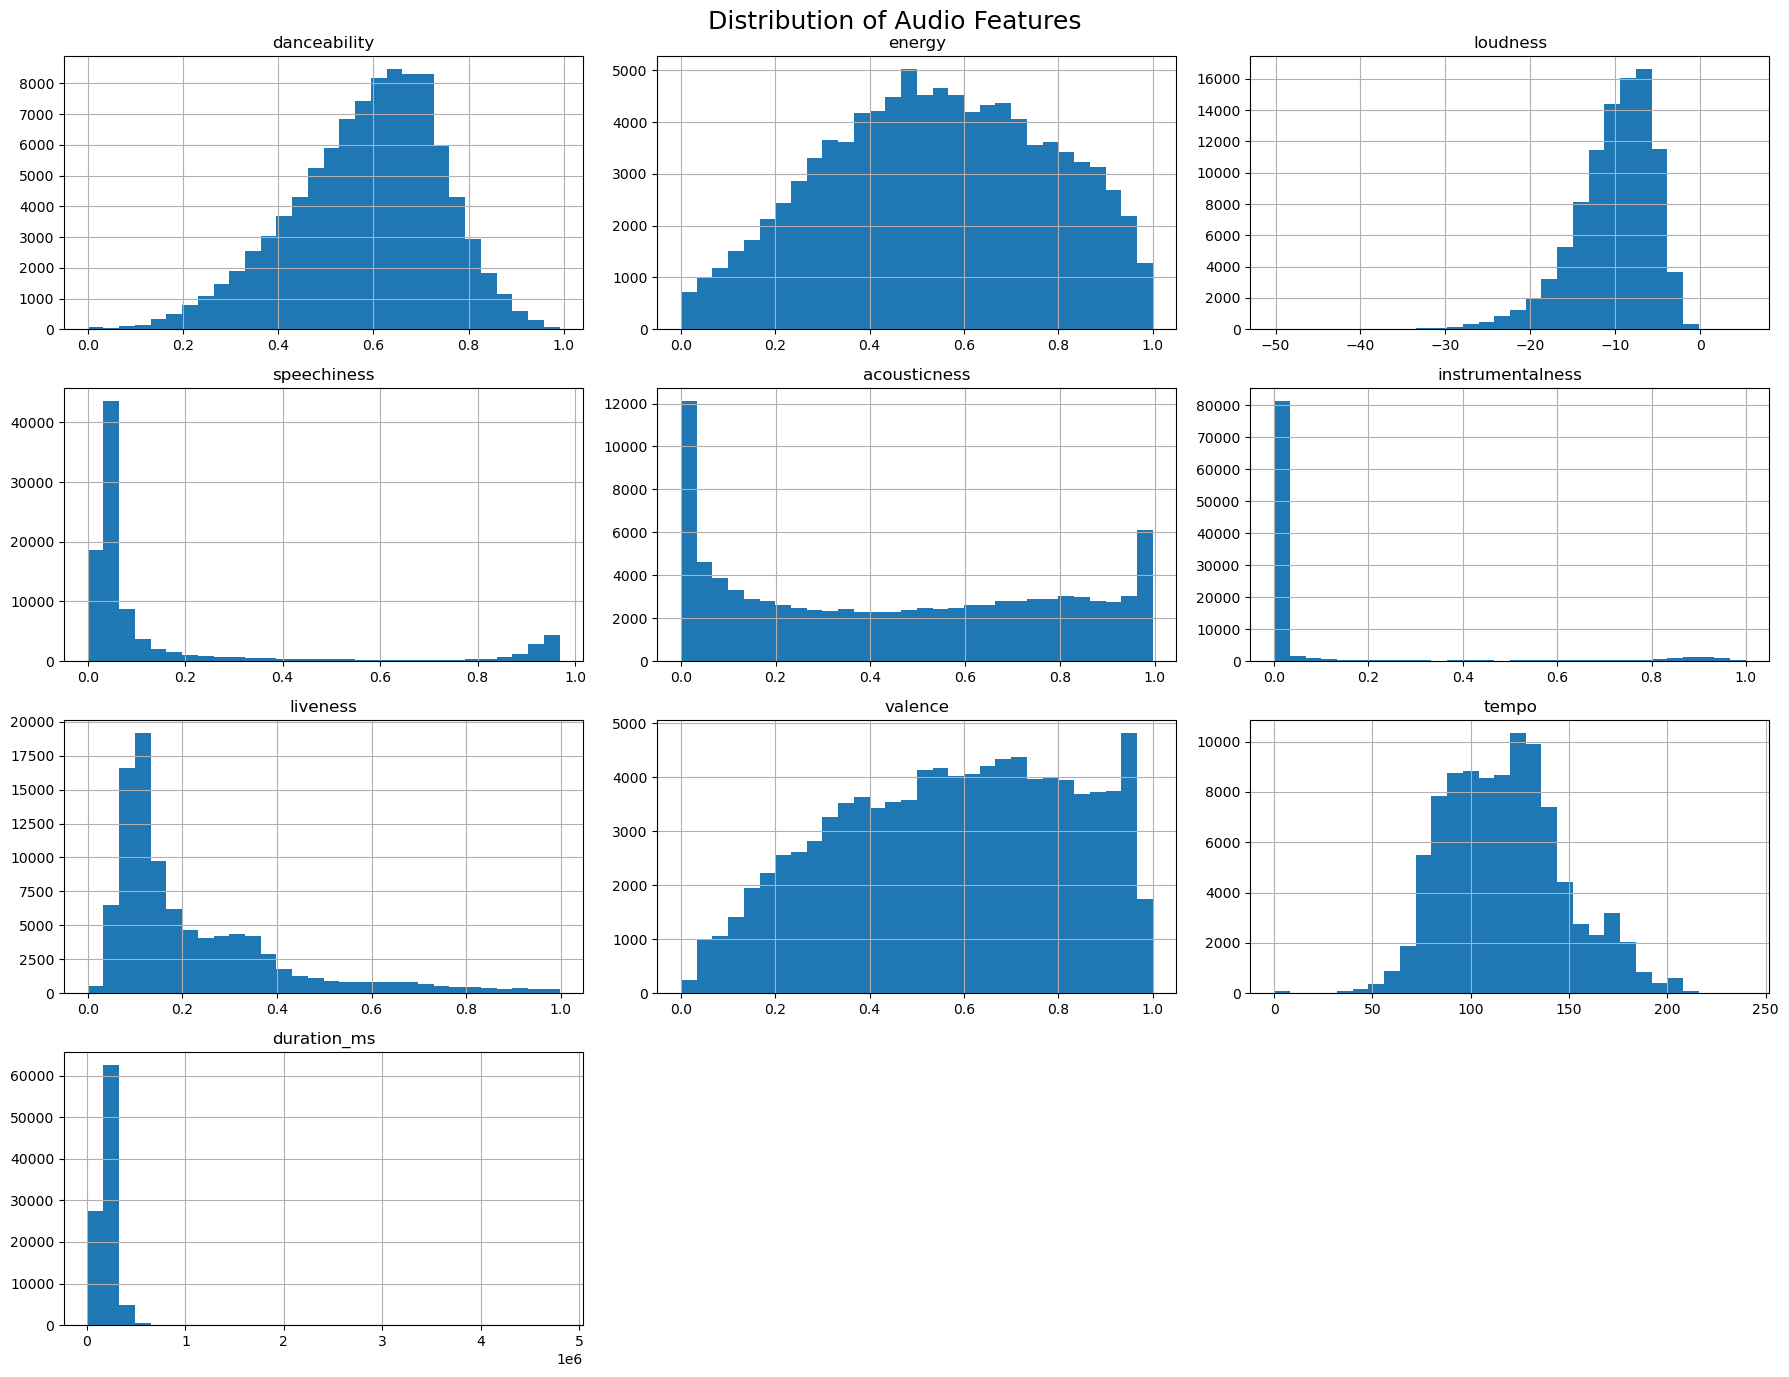

In [20]:
# ============================================
# DISTRIBUTION OF AUDIO FEATURES
# ============================================

X.hist(
    figsize=(18, 14),
    bins=30
)

plt.suptitle(
    "Distribution of Audio Features",
    fontsize=18
)

plt.tight_layout()
plt.show()

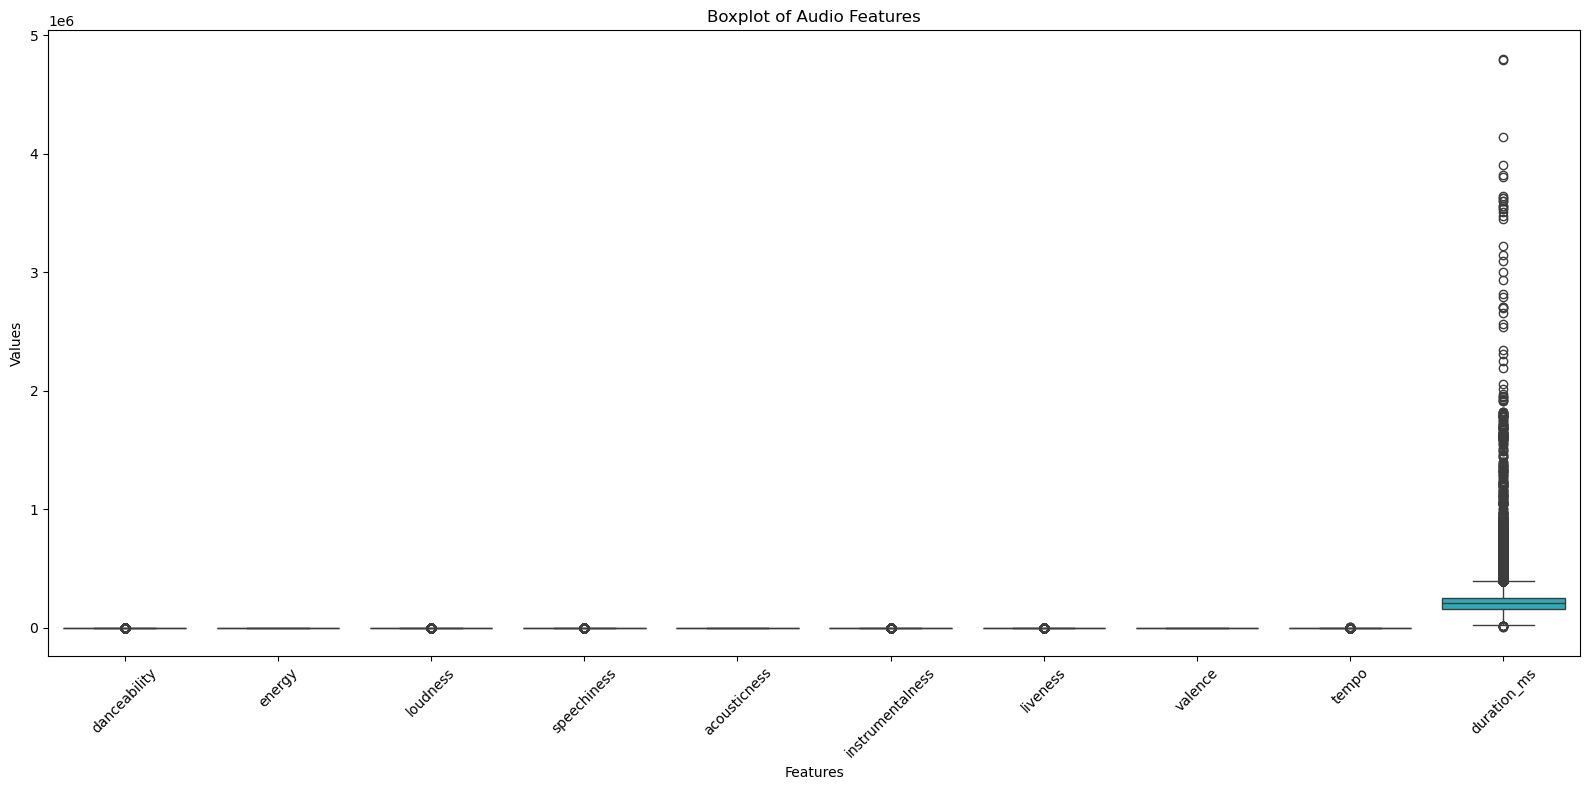

In [21]:
# ============================================
# BOX PLOTS
# ============================================

plt.figure(figsize=(16, 8))

sns.boxplot(data=X)

plt.title("Boxplot of Audio Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

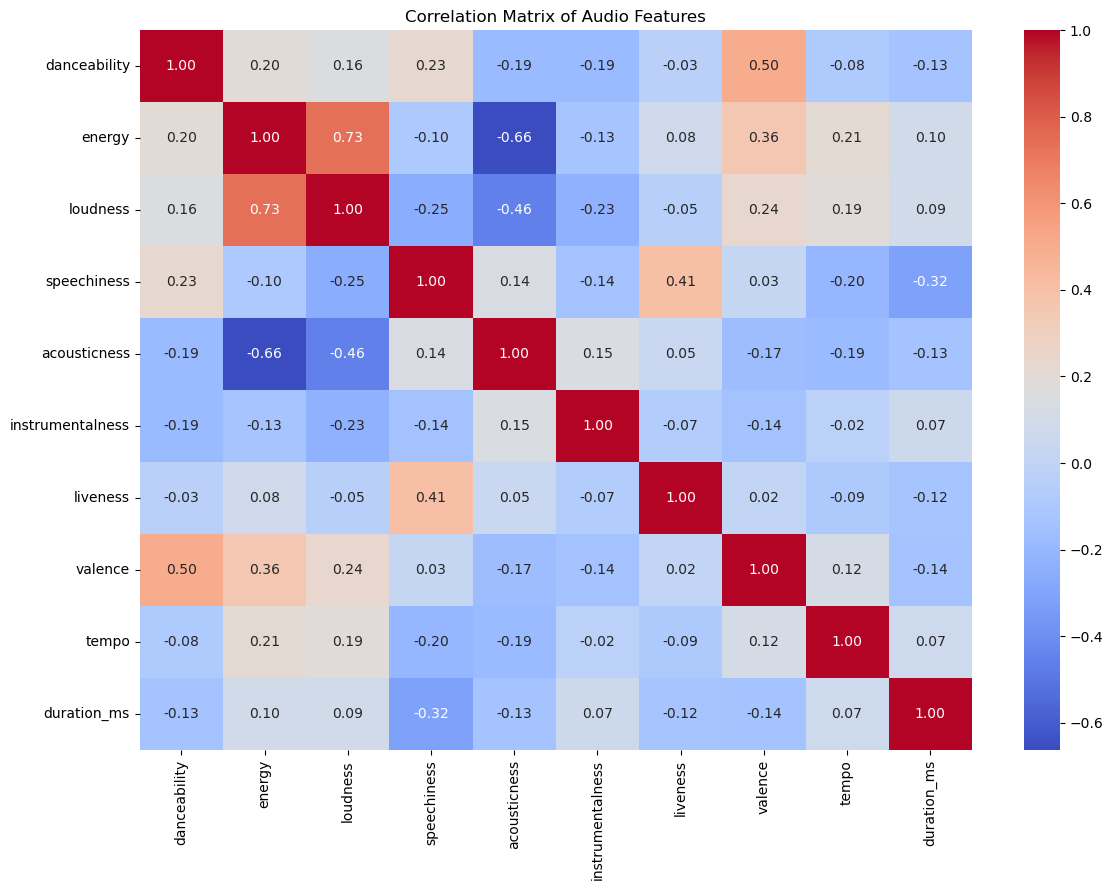

In [22]:
# ============================================
# CORRELATION MATRIX
# ============================================

correlation_matrix = X.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Audio Features")

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# FEATURE STATISTICS
# ============================================

feature_statistics = X.describe().T

feature_statistics

,count,mean,std,min,25%,50%,75%,max
danceability,95837.0,0.586853,0.155422,0.00000,0.4880,0.605000,0.7000,0.991
energy,95837.0,0.541083,0.236304,0.00002,0.3650,0.542000,0.7270,1.000
loudness,95837.0,-10.157862,4.748798,-50.17400,-12.7230,-9.397000,-6.6920,5.376
speechiness,95837.0,0.168832,0.275417,0.00000,0.0341,0.046200,0.1030,0.968
acousticness,95837.0,0.458989,0.330416,0.00000,0.1330,0.453000,0.7590,0.996
instrumentalness,95837.0,0.082145,0.232440,0.00000,0.0000,0.000004,0.0013,1.000
liveness,95837.0,0.224916,0.185829,0.00000,0.1000,0.149000,0.3020,0.997
valence,95837.0,0.574281,0.248126,0.00000,0.3780,0.589000,0.7800,1.000
tempo,95837.0,117.539870,30.190399,0.00000,94.8290,116.595000,135.9750,239.906
duration_ms,95837.0,208732.031835,117752.555950,6373.00000,157333.0000,204000.000000,250267.0000,4800118.000


In [24]:
# ============================================
# MINIMUM AND MAXIMUM VALUES
# ============================================

feature_range = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max(),
    "Mean": X.mean(),
    "Standard Deviation": X.std()
})

feature_range

,Minimum,Maximum,Mean,Standard Deviation
danceability,0.00000,0.991,0.586853,0.155422
energy,0.00002,1.000,0.541083,0.236304
loudness,-50.17400,5.376,-10.157862,4.748798
speechiness,0.00000,0.968,0.168832,0.275417
acousticness,0.00000,0.996,0.458989,0.330416
instrumentalness,0.00000,1.000,0.082145,0.232440
liveness,0.00000,0.997,0.224916,0.185829
valence,0.00000,1.000,0.574281,0.248126
tempo,0.00000,239.906,117.539870,30.190399
duration_ms,6373.00000,4800118.000,208732.031835,117752.555950


In [25]:
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed.
Scaled data shape: (95837, 10)


In [26]:
# ============================================
# CONVERT SCALED DATA INTO DATAFRAME
# ============================================

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=audio_features,
    index=X.index
)

X_scaled_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005,-0.401735
1,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,0.124906
2,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003,-0.003949
3,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268,-0.397437
4,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593,-0.346143


In [27]:
# ============================================
# CHECK SCALED MEAN
# ============================================

X_scaled_df.mean()

danceability        2.704655e-16
energy              7.592013e-17
loudness            7.592013e-17
speechiness        -7.592013e-17
acousticness       -9.490016e-17
instrumentalness    9.490016e-18
liveness           -2.847005e-17
valence             4.448445e-17
tempo              -1.992903e-16
duration_ms        -6.643011e-17
dtype: float64

In [28]:
# ============================================
# CHECK SCALED STANDARD DEVIATION
# ============================================

X_scaled_df.std()

danceability        1.000005
energy              1.000005
loudness            1.000005
speechiness         1.000005
acousticness        1.000005
instrumentalness    1.000005
liveness            1.000005
valence             1.000005
tempo               1.000005
duration_ms         1.000005
dtype: float64

In [29]:
# ============================================
# ELBOW METHOD
# ============================================

inertia = []

K_range = range(2, 11)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

print("Inertia values calculated successfully.")

Inertia values calculated successfully.


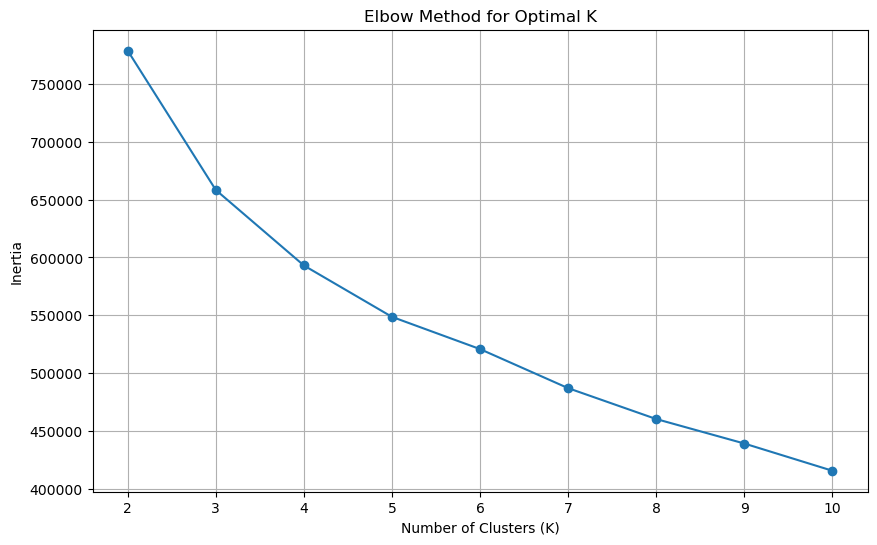

In [30]:
# ============================================
# ELBOW CURVE
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    list(K_range),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(list(K_range))
plt.grid(True)

plt.show()

In [31]:
# ============================================
# CELL 36 - SILHOUETTE SCORE
# ============================================

silhouette_scores = []

K_range = range(2, 11)

# Use a sample for faster calculation
sample_size = min(10000, len(X_scaled))

np.random.seed(42)

sample_indices = np.random.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

print("Calculating Silhouette Scores...")
print("Sample size:", sample_size)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k} | Silhouette Score = {score:.4f}"
    )

print("Silhouette calculation completed!")

Calculating Silhouette Scores...
Sample size: 10000
K = 2 | Silhouette Score = 0.1977
K = 3 | Silhouette Score = 0.2364
K = 4 | Silhouette Score = 0.2262
K = 5 | Silhouette Score = 0.1865
K = 6 | Silhouette Score = 0.1857
K = 7 | Silhouette Score = 0.1866
K = 8 | Silhouette Score = 0.1671
K = 9 | Silhouette Score = 0.1639
K = 10 | Silhouette Score = 0.1735
Silhouette calculation completed!


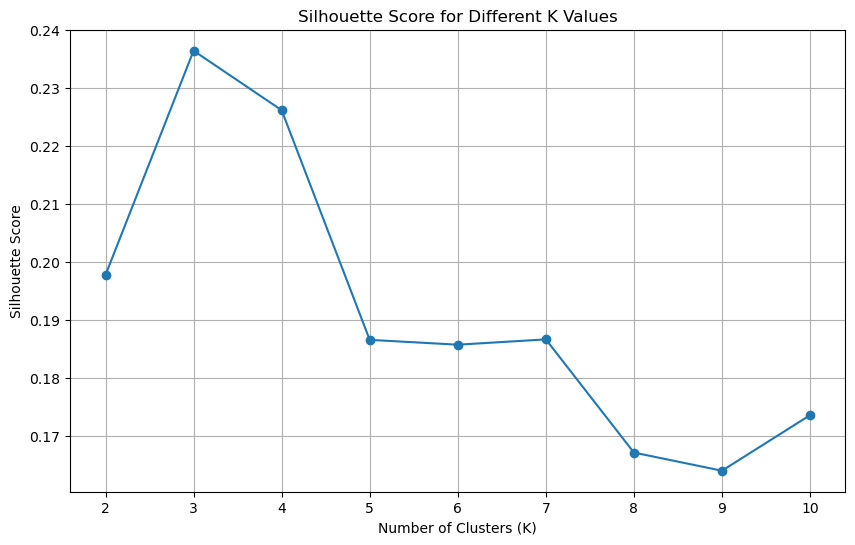

In [32]:
# ============================================
# CELL 37 - SILHOUETTE GRAPH
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title(
    "Silhouette Score for Different K Values"
)

plt.xticks(list(K_range))

plt.grid(True)

plt.show()

In [33]:
# ============================================
# BEST K BASED ON SILHOUETTE SCORE
# ============================================

best_k = list(K_range)[
    np.argmax(silhouette_scores)
]

best_silhouette = max(silhouette_scores)

print("Best K:", best_k)
print(
    "Best Silhouette Score:",
    round(best_silhouette, 4)
)

Best K: 3
Best Silhouette Score: 0.2364


In [34]:
# ============================================
# K VS SILHOUETTE SCORE
# ============================================

k_score_table = pd.DataFrame({
    "K": list(K_range),
    "Silhouette Score": silhouette_scores,
    "Inertia": inertia
})

k_score_table

,K,Silhouette Score,Inertia
0,2,0.197717,778813.594878
1,3,0.236442,658335.081270
2,4,0.226177,593031.033461
3,5,0.186531,548594.922240
4,6,0.185696,520710.604551
5,7,0.186612,486936.397533
6,8,0.167075,460215.406571
7,9,0.163939,439036.664994
8,10,0.173534,415491.731138


In [35]:
# ============================================
# FINAL K-MEANS MODEL
# ============================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Final K-Means model trained successfully.")

Final K-Means model trained successfully.


In [36]:
# ============================================
# ADD CLUSTER LABEL
# ============================================

df["cluster"] = cluster_labels

print("Cluster labels added to original dataset.")

df.head()

Cluster labels added to original dataset.


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,cluster
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.000016,0.325,0.654,133.088,3,5078,['vintage chanson'],Mistinguett,22,1
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.000000,0.128,0.431,78.459,3,5078,['vintage chanson'],Mistinguett,22,1
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.000000,0.418,0.481,70.443,4,5078,['vintage chanson'],Mistinguett,22,1
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.000000,0.219,0.726,129.775,4,5078,['vintage chanson'],Mistinguett,22,1
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.000000,0.373,0.844,75.950,4,5078,['vintage chanson'],Mistinguett,22,1


In [37]:
# ============================================
# CLUSTER SIZE
# ============================================

cluster_counts = (
    df["cluster"]
    .value_counts()
    .sort_index()
)

print("Number of songs in each cluster:")
print(cluster_counts)

Number of songs in each cluster:
cluster
0    12513
1    30807
2    52517
Name: count, dtype: int64


In [38]:
# ============================================
# CLUSTER PERCENTAGE
# ============================================

cluster_percentage = (
    df["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

cluster_percentage = cluster_percentage.round(2)

print("Percentage of songs in each cluster:")
print(cluster_percentage)

Percentage of songs in each cluster:
cluster
0    13.06
1    32.15
2    54.80
Name: proportion, dtype: float64


In [39]:
# ============================================
# CLUSTER SIZE TABLE
# ============================================

cluster_size_table = pd.DataFrame({
    "Number of Songs": cluster_counts,
    "Percentage": cluster_percentage
})

cluster_size_table

,Number of Songs,Percentage
cluster,,
0,12513,13.06
1,30807,32.15
2,52517,54.80


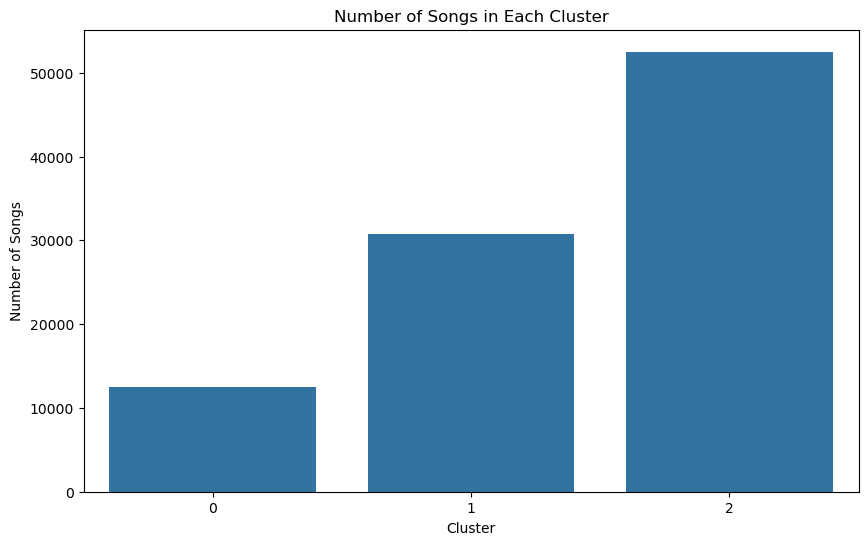

In [40]:
# ============================================
# CLUSTER SIZE VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x=cluster_size_table.index,
    y=cluster_size_table["Number of Songs"]
)

plt.title("Number of Songs in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")

plt.show()

In [41]:
# ============================================
# FINAL SILHOUETTE SCORE
# ============================================

final_silhouette_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print(
    "Final Silhouette Score:",
    round(final_silhouette_score, 4)
)

Final Silhouette Score: 0.2423


In [42]:
# ============================================
# DAVIES-BOULDIN INDEX
# ============================================

davies_bouldin = davies_bouldin_score(
    X_scaled,
    cluster_labels
)

print(
    "Davies-Bouldin Index:",
    round(davies_bouldin, 4)
)

Davies-Bouldin Index: 1.5702


In [43]:
# ============================================
# CLUSTER PROFILE
# ============================================

cluster_profile = df.groupby(
    "cluster"
)[audio_features].mean()

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.664271,0.466636,-13.363885,0.829978,0.585932,0.001385,0.435535,0.584036,100.389473,97520.590026
1,0.486381,0.311231,-13.205013,0.060140,0.749228,0.168547,0.182070,0.413254,111.939598,223457.063979
2,0.627345,0.693655,-7.606487,0.075064,0.258485,0.050703,0.199867,0.666416,124.911397,226592.052516


In [44]:
# ============================================
# ROUNDED CLUSTER PROFILE
# ============================================

cluster_profile_rounded = cluster_profile.round(3)

cluster_profile_rounded

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.664,0.467,-13.364,0.830,0.586,0.001,0.436,0.584,100.389,97520.590
1,0.486,0.311,-13.205,0.060,0.749,0.169,0.182,0.413,111.940,223457.064
2,0.627,0.694,-7.606,0.075,0.258,0.051,0.200,0.666,124.911,226592.053


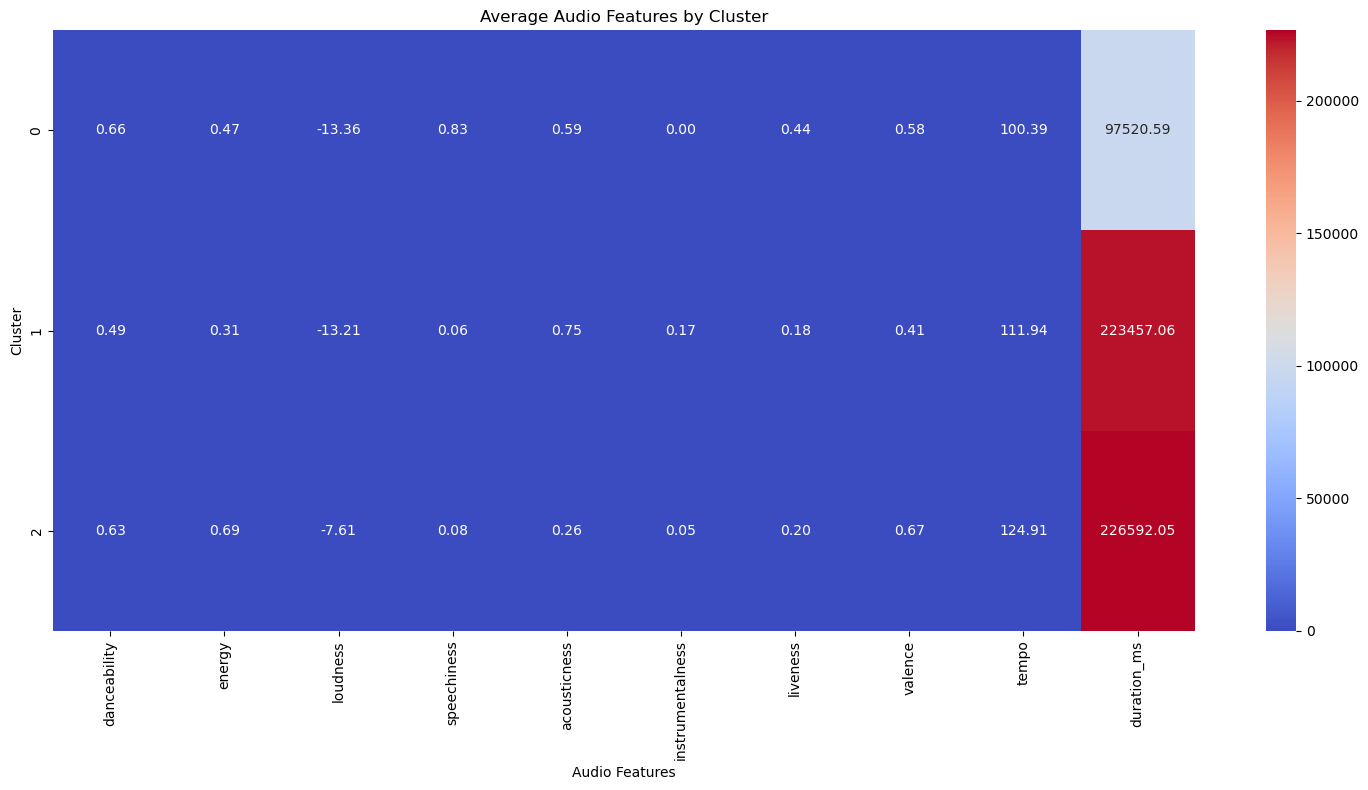

In [45]:
# ============================================
# CLUSTER PROFILE HEATMAP
# ============================================

plt.figure(figsize=(15, 8))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Average Audio Features by Cluster")
plt.xlabel("Audio Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [46]:
# ============================================
# DOMINANT FEATURES IN EACH CLUSTER
# ============================================

for cluster in cluster_profile.index:
    
    print("\nCluster", cluster)
    
    cluster_values = cluster_profile.loc[cluster]
    
    highest_features = (
        cluster_values
        .sort_values(ascending=False)
        .head(3)
    )
    
    print(highest_features)


Cluster 0
duration_ms    97520.590026
tempo            100.389473
speechiness        0.829978
Name: 0, dtype: float64

Cluster 1
duration_ms     223457.063979
tempo              111.939598
acousticness         0.749228
Name: 1, dtype: float64

Cluster 2
duration_ms    226592.052516
tempo             124.911397
energy              0.693655
Name: 2, dtype: float64


In [47]:
# ============================================
# LOWEST FEATURES IN EACH CLUSTER
# ============================================

for cluster in cluster_profile.index:
    
    print("\nCluster", cluster)
    
    cluster_values = cluster_profile.loc[cluster]
    
    lowest_features = (
        cluster_values
        .sort_values()
        .head(3)
    )
    
    print(lowest_features)


Cluster 0
loudness           -13.363885
instrumentalness     0.001385
liveness             0.435535
Name: 0, dtype: float64

Cluster 1
loudness           -13.205013
speechiness          0.060140
instrumentalness     0.168547
Name: 1, dtype: float64

Cluster 2
loudness           -7.606487
instrumentalness    0.050703
speechiness         0.075064
Name: 2, dtype: float64


In [48]:
# ============================================
# PCA
# ============================================

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed.")
print("PCA shape:", X_pca.shape)

PCA completed.
PCA shape: (95837, 2)


In [49]:
# ============================================
# PCA EXPLAINED VARIANCE
# ============================================

pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100

total_variance = (
    pca.explained_variance_ratio_.sum() * 100
)

print(
    "PC1 explains:",
    round(pc1_variance, 2),
    "%"
)

print(
    "PC2 explains:",
    round(pc2_variance, 2),
    "%"
)

print(
    "Total variance explained:",
    round(total_variance, 2),
    "%"
)

PC1 explains: 27.08 %
PC2 explains: 18.82 %
Total variance explained: 45.9 %


In [50]:
# ============================================
# PCA DATAFRAME
# ============================================

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = cluster_labels

pca_df.head()

,PC1,PC2,cluster
0,-1.676304,0.291571,1
1,-2.639968,-0.472803,1
2,-2.537328,0.474464,1
3,-0.677418,0.709757,1
4,-1.480657,1.426716,1


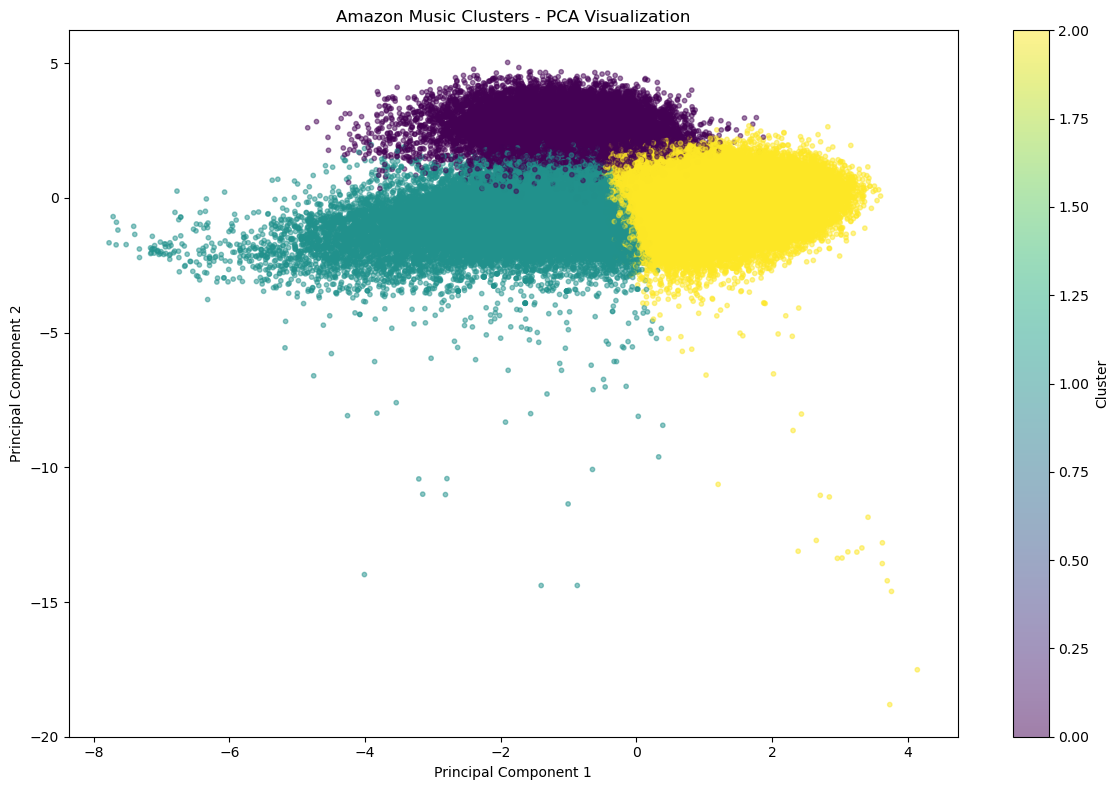

In [51]:
# ============================================
# PCA CLUSTER VISUALIZATION
# ============================================

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Amazon Music Clusters - PCA Visualization"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()
plt.show()

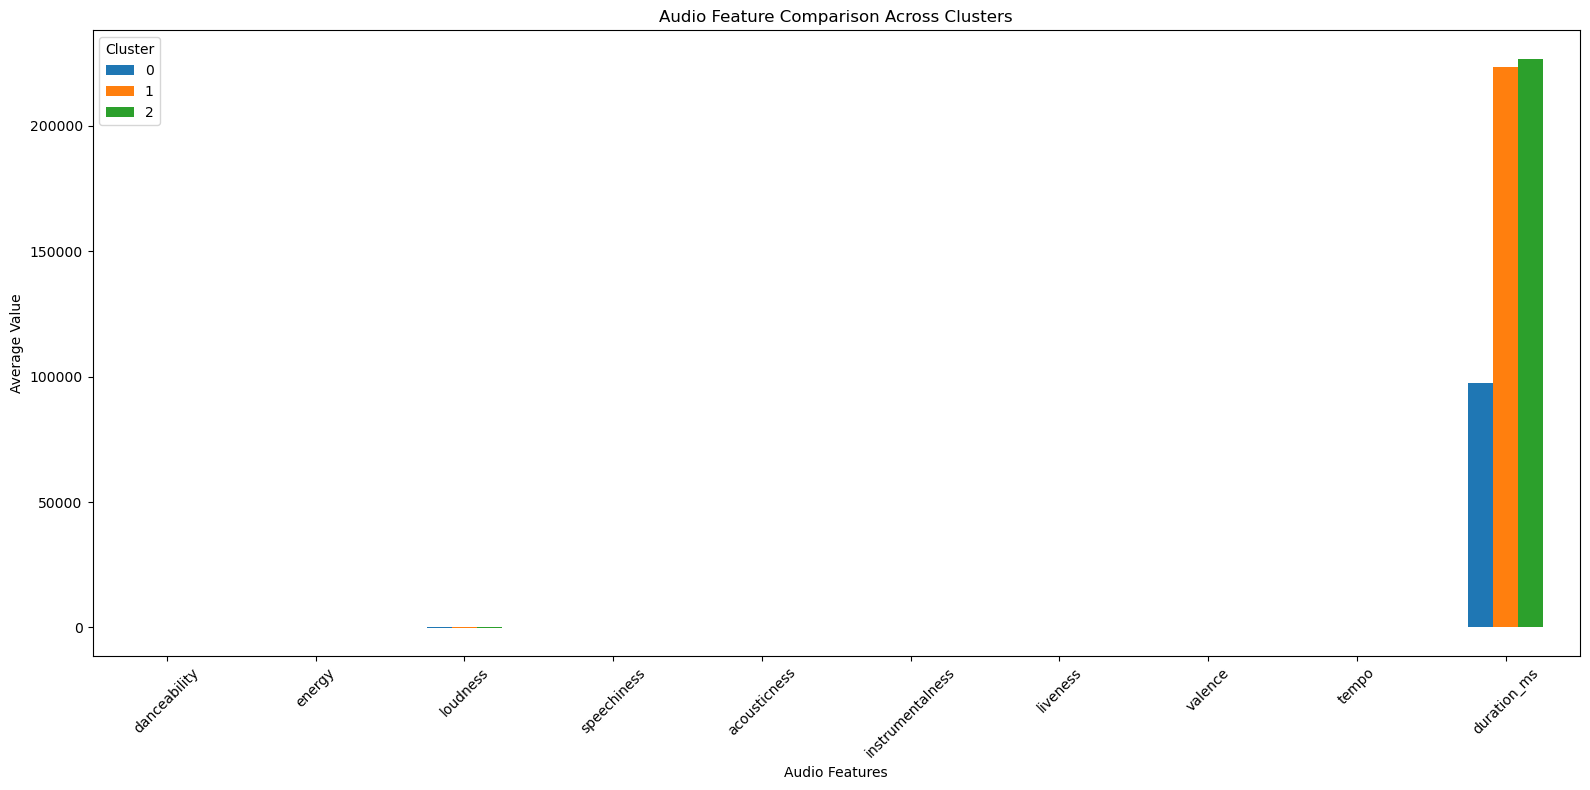

In [52]:
# ============================================
# FEATURE COMPARISON ACROSS CLUSTERS
# ============================================

cluster_profile.T.plot(
    kind="bar",
    figsize=(16, 8)
)

plt.title(
    "Audio Feature Comparison Across Clusters"
)

plt.xlabel("Audio Features")
plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [53]:
# ============================================
# NUMBER OF SONGS PER CLUSTER
# ============================================

for cluster in sorted(df["cluster"].unique()):
    
    print(
        f"Cluster {cluster}: "
        f"{len(df[df['cluster'] == cluster])} songs"
    )

Cluster 0: 12513 songs
Cluster 1: 30807 songs
Cluster 2: 52517 songs


In [54]:
# ============================================
# SAMPLE SONGS FROM EACH CLUSTER
# ============================================

for cluster in sorted(df["cluster"].unique()):
    
    print("\n")
    print("=" * 60)
    print("CLUSTER", cluster)
    print("=" * 60)
    
    cluster_songs = df[
        df["cluster"] == cluster
    ]
    
    display(
        cluster_songs[
            [
                "name_song",
                "name_artists",
                "popularity_songs",
                "cluster"
            ]
        ].head(10)
    )



CLUSTER 0


,name_song,name_artists,popularity_songs,cluster
37,Dites Moi Doumergue,Perchicot,0,0
43,Il N'osait Pas Se Decider,Georgius,0,0
50,L'amour Excuse Tout,Georgius,0,0
55,Le Genre De La Maison,Georgius,0,0
58,Le Piéton,Georgius,0,0
60,Oh Oh Il Travaille Du Chapeau,Georgius,0,0
63,C'est Jeune Et Ca N'sait Pas,Fortugé,0,0
104,Big Fat Ma and Skinny Pa,Louis Armstrong & His Hot Five,3,0
108,Big Fat Ma And Skinny Pa,Louis Armstrong & His Hot Five,0,0
146,A Monday Date,Louis Armstrong & His Hot Five,0,0




CLUSTER 1


,name_song,name_artists,popularity_songs,cluster
0,La Java,Mistinguett,0,1
1,En Douce,Mistinguett,0,1
2,J'en Ai Marre,Mistinguett,0,1
3,Ils n'ont pas ca,Mistinguett,0,1
4,La belote,Mistinguett,0,1
5,Oh mademoiselle,Mistinguett,0,1
6,Il m'a vue nue,Mistinguett,0,1
7,Mon Bus'ness,Mistinguett,0,1
8,Ça c'est Paris,Mistinguett,0,1
9,Le Fado,Mistinguett,0,1




CLUSTER 2


,name_song,name_artists,popularity_songs,cluster
15,On M'suit,Mistinguett,0,2
34,Je N'suis Pas Celle Que Vous Croyez,Perchicot,0,2
38,La Noce À Rebecca,Perchicot,0,2
128,Hotter Than That,Louis Armstrong & His Hot Five,3,2
152,Sunset Cafe Stomp,Louis Armstrong & His Hot Five,3,2
188,Sunset Cafe Stomp,Louis Armstrong & His Hot Five,0,2
199,Hotter Than That,Louis Armstrong & His Hot Five,0,2
200,Sunset Cafe Stomp,Louis Armstrong & His Hot Five,0,2
215,Hotter Than That,Louis Armstrong & His Hot Five,0,2
230,Sunset Cafe Stomp,Louis Armstrong & His Hot Five,11,2


In [55]:
# ============================================
# MOST POPULAR SONGS IN EACH CLUSTER
# ============================================

for cluster in sorted(df["cluster"].unique()):
    
    print("\n")
    print("=" * 60)
    print("CLUSTER", cluster)
    print("=" * 60)
    
    cluster_songs = (
        df[df["cluster"] == cluster]
        .sort_values(
            by="popularity_songs",
            ascending=False
        )
    )
    
    display(
        cluster_songs[
            [
                "name_song",
                "name_artists",
                "popularity_songs"
            ]
        ].head(10)
    )



CLUSTER 0


,name_song,name_artists,popularity_songs
61359,Siempre Fine,Ak4:20,72
35294,Beautiful Pain (Losin My Mind),Polo G,72
35292,Neva Cared,Polo G,70
34969,Gentleman,SL,70
90870,The Chicken Wing Beat,Ricky Desktop,70
34514,Ain't Nobody Takin My Baby,Russ,69
41676,VIP in der Psychiatrie,K.I.Z,65
83502,Pot-Pourri: Temporal / Velocidade da Luz - Ao ...,Thiaguinho,63
61354,Ella Se Arrebata,Ak4:20,63
34511,You Reposted in the Wrong Neighborhood I Glue7...,Shokk,63




CLUSTER 1


,name_song,name_artists,popularity_songs
35233,Arcade,Duncan Laurence,89
35436,Put Your Records On,Ritt Momney,87
35234,Arcade,Duncan Laurence,83
34858,Hold On,Chord Overstreet,83
34884,Beautiful Crazy,Luke Combs,80
34650,Go Fuck Yourself,Two Feet,80
35505,Control,Zoe Wees,80
35303,YKWIM?,Yot Club,79
35746,Weak,Larissa Lambert,79
35582,ALL GIRLS ARE THE SAME,RØNIN,79




CLUSTER 2


,name_song,name_artists,popularity_songs
35665,Astronaut In The Ocean,Masked Wolf,98
35398,WITHOUT YOU,The Kid LAROI,94
35422,Hecha Pa' Mi,Boza,92
35532,911,Sech,91
35241,What You Know Bout Love,Pop Smoke,91
35432,Whoopty,CJ,89
35287,RAPSTAR,Polo G,89
35434,Goosebumps,HVME,89
35284,Martin & Gina,Polo G,88
35668,Tapão Na Raba,Raí Saia Rodada,87


In [56]:
# ============================================
# NUMBER OF UNIQUE ARTISTS PER CLUSTER
# ============================================

artist_cluster_summary = (
    df.groupby("cluster")["name_artists"]
    .nunique()
)

print(
    "Unique artists in each cluster:"
)

print(artist_cluster_summary)

Unique artists in each cluster:
cluster
0      650
1     7657
2    13638
Name: name_artists, dtype: int64


In [57]:
# ============================================
# TOP ARTISTS BY NUMBER OF SONGS
# ============================================

for cluster in sorted(df["cluster"].unique()):
    
    print("\n")
    print("=" * 60)
    print("CLUSTER", cluster)
    print("=" * 60)
    
    top_artists = (
        df[df["cluster"] == cluster]["name_artists"]
        .value_counts()
        .head(10)
    )
    
    print(top_artists)



CLUSTER 0
name_artists
Die drei ???                    3498
TKKG Retro-Archiv               1915
Benjamin Blümchen               1494
Bibi Blocksberg                 1428
Fünf Freunde                     782
Globi                            554
H.P. Lovecraft                   220
Hanni und Nanni                  160
Hui Buh, das Schlossgespenst     138
Margaretha Krook                  92
Name: count, dtype: int64


CLUSTER 1
name_artists
Charlie Chaplin                   295
Louis Armstrong & His Hot Five    242
Bill Evans                        176
Ahmet Kaya                        158
David and the High Spirit         149
Charles Aznavour                  146
Müslüm Gürses                     132
湯蘭花                               127
Sezen Aksu                        112
S. P. Balasubrahmanyam            110
Name: count, dtype: int64


CLUSTER 2
name_artists
Die drei ???              288
ARASHI                    226
S. P. Balasubrahmanyam    199
Karibe con K              175
Win

In [58]:
# ============================================
# AVERAGE SONG POPULARITY BY CLUSTER
# ============================================

popularity_by_cluster = (
    df.groupby("cluster")["popularity_songs"]
    .mean()
    .round(2)
)

popularity_by_cluster

cluster
0    28.17
1    20.71
2    28.71
Name: popularity_songs, dtype: float64

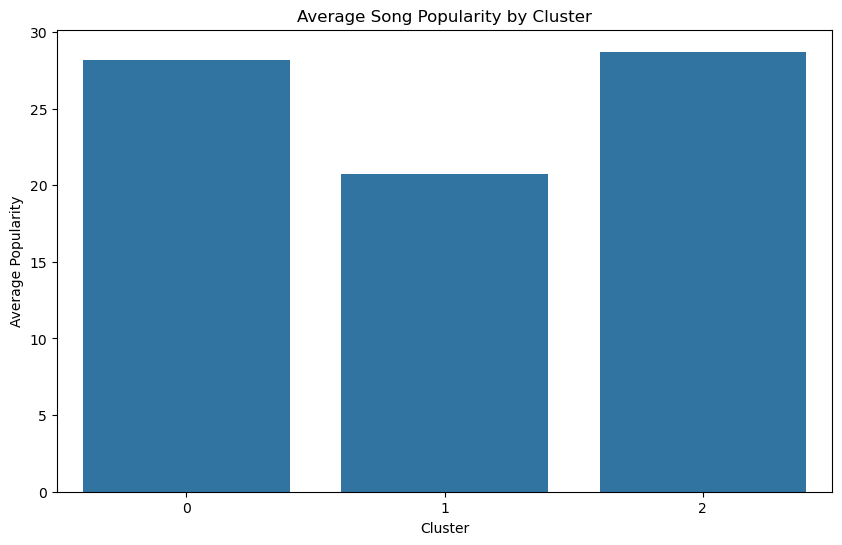

In [59]:
# ============================================
# POPULARITY BY CLUSTER
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x=popularity_by_cluster.index,
    y=popularity_by_cluster.values
)

plt.title("Average Song Popularity by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Popularity")

plt.show()

In [60]:
# ============================================
# FINAL CLUSTER SUMMARY
# ============================================

cluster_summary = cluster_profile.copy()

cluster_summary["song_count"] = (
    df.groupby("cluster").size()
)

cluster_summary["percentage"] = (
    df["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .values * 100
)

cluster_summary["average_popularity"] = (
    df.groupby("cluster")["popularity_songs"]
    .mean()
)

cluster_summary.round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,song_count,percentage,average_popularity
cluster,,,,,,,,,,,,,
0,0.664,0.467,-13.364,0.830,0.586,0.001,0.436,0.584,100.389,97520.590,12513,13.057,28.167
1,0.486,0.311,-13.205,0.060,0.749,0.169,0.182,0.413,111.940,223457.064,30807,32.145,20.708
2,0.627,0.694,-7.606,0.075,0.258,0.051,0.200,0.666,124.911,226592.053,52517,54.798,28.709


In [61]:
# ============================================
# FINAL PROJECT METRICS
# ============================================

print("=" * 60)
print("AMAZON MUSIC CLUSTERING - FINAL METRICS")
print("=" * 60)

print("Total Songs:", len(df))

print("Total Features Used:", len(audio_features))

print("Number of Clusters:", best_k)

print(
    "Silhouette Score:",
    round(final_silhouette_score, 4)
)

print(
    "Davies-Bouldin Index:",
    round(davies_bouldin, 4)
)

print(
    "PCA Variance Explained:",
    round(total_variance, 2),
    "%"
)

print("=" * 60)

AMAZON MUSIC CLUSTERING - FINAL METRICS
Total Songs: 95837
Total Features Used: 10
Number of Clusters: 3
Silhouette Score: 0.2423
Davies-Bouldin Index: 1.5702
PCA Variance Explained: 45.9 %


In [62]:
# ============================================
# SAVE FINAL DATASET
# ============================================

output_file = r"C:\\Users\\ABHISHEK\\Documents\\Data Science\\Amazon Music Clustering project\\amazon_music_clustered.csv"

df.to_csv(
    output_file,
    index=False
)

print("Final dataset saved successfully!")
print("File name:", output_file )

Final dataset saved successfully!
File name: C:\\Users\\ABHISHEK\\Documents\\Data Science\\Amazon Music Clustering project\\amazon_music_clustered.csv


In [63]:
# ============================================
# SAVE CLUSTER PROFILE
# ============================================

cluster_profile.to_csv(
    r"C:\\Users\\ABHISHEK\\Documents\\Data Science\\Amazon Music Clustering project\\cluster_profile.csv"
)

print("Cluster profile saved successfully!")

Cluster profile saved successfully!


In [64]:
# ============================================
# SAVE K EVALUATION RESULTS
# ============================================

k_score_table.to_csv(
    r"C:\\Users\\ABHISHEK\\Documents\\Data Science\\Amazon Music Clustering project\\k_evaluation_results.csv",
    index=False
)

print("K evaluation results saved successfully!")

K evaluation results saved successfully!


In [65]:
# ============================================
# VERIFY FINAL CSV
# ============================================

final_df = pd.read_csv(
    "amazon_music_clustered.csv"
)

print("Final CSV loaded successfully.")

print("Final Shape:")
print(final_df.shape)

print("\nFinal Columns:")
print(list(final_df.columns))

Final CSV loaded successfully.
Final Shape:
(95837, 24)

Final Columns:
['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit', 'id_artists', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres', 'name_artists', 'popularity_artists', 'cluster']


In [66]:
# ============================================
# VERIFY CLUSTER COLUMN
# ============================================

print(
    final_df["cluster"].value_counts().sort_index()
)

cluster
0    12513
1    30807
2    52517
Name: count, dtype: int64


In [67]:
# ============================================
# FINAL 5 ROWS
# ============================================

final_df.tail()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,cluster
95832,44r4zta6P9flkhKaVnbsvG,Freaks,70,174800,0,14Y3trk7LaslSFTk1G35rx,25-02-2019,0.674,0.5680,1,...,0.000,0.1650,0.640,166.107,4,16057,['alt z'],Jordan Clarke,56,2
95833,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,5VGgFE9nPgMfEnYiPT5J2B,25-02-2020,0.528,0.6730,4,...,0.000,0.0989,0.297,130.066,4,929,['chinese viral pop'],芝麻,36,2
95834,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,7vgGpuiXdNlCmc994PlMlz,30-10-2020,0.609,0.0172,8,...,0.973,0.1080,0.890,68.619,4,23,['instrumental lullaby'],Laureen Conrad,52,1
95835,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,4MxqhahGRT4BPz1PilXGeu,20-03-2020,0.562,0.0331,1,...,0.961,0.1110,0.386,63.696,3,91,['instrumental lullaby'],Gregory Oberle,55,1
95836,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,1QLBXKM5GCpyQQSVMNZqrZ,26-09-2020,0.560,0.5180,0,...,0.000,0.0648,0.211,131.896,4,896,['chinese viral pop'],阿YueYue,38,1


In [68]:
# ============================================
# PROJECT REPORT SUMMARY
# ============================================

print("""
============================================================
              AMAZON MUSIC CLUSTERING
                 PROJECT SUMMARY
============================================================

PROJECT OBJECTIVE:
To group similar songs based on their audio characteristics
using unsupervised machine learning.

MACHINE LEARNING TECHNIQUE:
K-Means Clustering

FEATURE SCALING:
StandardScaler

DIMENSIONALITY REDUCTION:
PCA

EVALUATION METHODS:
1. Elbow Method
2. Silhouette Score
3. Davies-Bouldin Index
4. Cluster Size Analysis
5. Feature Interpretability

AUDIO FEATURES USED:
""")

for feature in audio_features:
    print("-", feature)

print("\nFINAL RESULTS")
print("-" * 60)

print("Total Songs:", len(df))
print("Features Used:", len(audio_features))
print("Selected Number of Clusters:", best_k)

print(
    "Silhouette Score:",
    round(final_silhouette_score, 4)
)

print(
    "Davies-Bouldin Index:",
    round(davies_bouldin, 4)
)

print(
    "PCA Variance Explained:",
    round(total_variance, 2),
    "%"
)

print("\nCluster Sizes:")
print(cluster_counts)

print("\n============================================================")


              AMAZON MUSIC CLUSTERING
                 PROJECT SUMMARY

PROJECT OBJECTIVE:
To group similar songs based on their audio characteristics
using unsupervised machine learning.

MACHINE LEARNING TECHNIQUE:
K-Means Clustering

FEATURE SCALING:
StandardScaler

DIMENSIONALITY REDUCTION:
PCA

EVALUATION METHODS:
1. Elbow Method
2. Silhouette Score
3. Davies-Bouldin Index
4. Cluster Size Analysis
5. Feature Interpretability

AUDIO FEATURES USED:

- danceability
- energy
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo
- duration_ms

FINAL RESULTS
------------------------------------------------------------
Total Songs: 95837
Features Used: 10
Selected Number of Clusters: 3
Silhouette Score: 0.2423
Davies-Bouldin Index: 1.5702
PCA Variance Explained: 45.9 %

Cluster Sizes:
cluster
0    12513
1    30807
2    52517
Name: count, dtype: int64



In [69]:
# ============================================
# FINAL PROJECT CHECKLIST
# ============================================

print("=" * 60)
print("PROJECT COMPLETION CHECKLIST")
print("=" * 60)

print("✓ Dataset loaded")
print("✓ Dataset explored")
print("✓ Data types checked")
print("✓ Missing values checked")
print("✓ Duplicate values checked")
print("✓ Audio features selected")
print("✓ Data cleaned")
print("✓ EDA completed")
print("✓ Distribution plots created")
print("✓ Boxplots created")
print("✓ Correlation heatmap created")
print("✓ Features standardized")
print("✓ Elbow Method completed")
print("✓ Silhouette Score completed")
print("✓ Best K selected")
print("✓ K-Means model trained")
print("✓ Cluster labels created")
print("✓ Cluster sizes analyzed")
print("✓ Davies-Bouldin Index calculated")
print("✓ Cluster profiles created")
print("✓ PCA completed")
print("✓ PCA visualization created")
print("✓ Feature comparison created")
print("✓ Song analysis completed")
print("✓ Artist analysis completed")
print("✓ Final CSV exported")
print("✓ Cluster profile exported")
print("✓ K evaluation exported")

print("=" * 60)
print("PROJECT ANALYSIS COMPLETED!")
print("=" * 60)

PROJECT COMPLETION CHECKLIST
✓ Dataset loaded
✓ Dataset explored
✓ Data types checked
✓ Missing values checked
✓ Duplicate values checked
✓ Audio features selected
✓ Data cleaned
✓ EDA completed
✓ Distribution plots created
✓ Boxplots created
✓ Correlation heatmap created
✓ Features standardized
✓ Elbow Method completed
✓ Silhouette Score completed
✓ Best K selected
✓ K-Means model trained
✓ Cluster labels created
✓ Cluster sizes analyzed
✓ Davies-Bouldin Index calculated
✓ Cluster profiles created
✓ PCA completed
✓ PCA visualization created
✓ Feature comparison created
✓ Song analysis completed
✓ Artist analysis completed
✓ Final CSV exported
✓ Cluster profile exported
✓ K evaluation exported
PROJECT ANALYSIS COMPLETED!
